# Clasificación de letras escritas a mano con redes neuronales

En este cuaderno vas a entrenar un modelo para clasificar imágenes de letras escritas a mano. Vamos a trabajar con EMNIST Letters, una extensión de MNIST orientada a caracteres alfabéticos.

## Objetivos de aprendizaje

Al finalizar este cuaderno, vas a poder:

- cargar un dataset de imágenes desde TensorFlow Datasets;
- preprocesar imágenes y etiquetas;
- entrenar una red densa para clasificación multiclase;
- evaluar el rendimiento del modelo;
- interpretar predicciones y una matriz de confusión.

## Microglosario

- **Clase**: categoría que el modelo debe predecir. En este caso, una letra.
- **Etiqueta**: respuesta correcta asociada a una imagen.
- **Normalización**: transformación de los valores de píxeles para que queden en una escala más conveniente.
- **Softmax**: función que convierte la salida del modelo en probabilidades por clase.
- **Matriz de confusión**: tabla que muestra aciertos y errores por clase.

## 1. Preparar herramientas

La primera celda instala dependencias si trabajás en Colab. Si ya las tenés instaladas, podés omitir la línea de instalación.

In [1]:
# Este bloque prepara el entorno instalando librerias o dependencias necesarias; sin esas librerias el 
# resto del notebook no podria importar modelos, cargar datos o construir la interfaz.
# En Colab puede ser necesario instalar estas bibliotecas.
# Si trabajás en un entorno local ya preparado, podés comentar esta línea.
!pip install -q seaborn

import math

import matplotlib.pyplot as plt   # Para graficar imágenes y curvas
import numpy as np                # Para operaciones con arrays
import seaborn as sns             # Para visualizar la matriz de confusión como heatmap
import tensorflow as tf           # Para construir y entrenar la red neuronal
import tensorflow_datasets as tfds  # Para descargar y cargar el dataset EMNIST
from sklearn.metrics import confusion_matrix  # Para calcular la matriz de confusión

print("Herramientas cargadas.")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Herramientas cargadas.


## 2. Cargar EMNIST Letters

EMNIST Letters contiene imágenes de letras escritas a mano. Cada imagen tiene una etiqueta que indica qué letra representa.

In [2]:
# Este bloque carga y organiza el conjunto de datos; un modelo aprende a partir de ejemplos; 
# por eso primero se define de donde vienen las imágenes o mediciones y como se separan sus 
# etiquetas.
print("Descargando y cargando el dataset EMNIST Letters. La primera ejecución puede tardar unos minutos.")

# Carga el dataset: as_supervised=True devuelve pares (imagen, etiqueta)
# with_info=True devuelve los metadatos del dataset (cantidad de ejemplos, clases, etc.)
datos, metadatos = tfds.load(
    "emnist/letters",
    as_supervised=True,
    with_info=True,
)

# Construye la lista de nombres de clases: EMNIST usa etiquetas numéricas 1-26
# chr(indice + ord("a") - 1) convierte 1 → "a", 2 → "b", ..., 26 → "z"
nombres_clases = []
for indice in range(1, 27):
    letra = chr(indice + ord("a") - 1)
    nombres_clases.append(letra)

# Obtiene la cantidad de ejemplos disponibles en cada partición
cantidad_entrenamiento = metadatos.splits["train"].num_examples
cantidad_prueba        = metadatos.splits["test"].num_examples
total                  = cantidad_entrenamiento + cantidad_prueba
porc_prueba            = cantidad_prueba / total * 100

print(f"Imágenes de entrenamiento: {cantidad_entrenamiento:,}")
print(f"Imágenes de prueba:        {cantidad_prueba:,}")
print(f"División:                  {100 - porc_prueba:.0f}% entrenamiento / {porc_prueba:.0f}% prueba")
print(f"Clases:                    {nombres_clases}")
print(f"\n→ Línea base por azar: {1 / len(nombres_clases) * 100:.1f}%  "
      f"(si el modelo eligiera al azar entre {len(nombres_clases)} letras)")

Descargando y cargando el dataset EMNIST Letters. La primera ejecución puede tardar unos minutos.
Imágenes de entrenamiento: 88,800
Imágenes de prueba:        14,800
División:                  86% entrenamiento / 14% prueba
Clases:                    ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

→ Línea base por azar: 3.8%  (si el modelo eligiera al azar entre 26 letras)


### Resumen 

**Que se hizo:** se carga y organiza el conjunto de datos.

**Por que se hizo:** un modelo aprende a partir de ejemplos; por eso primero se define de donde vienen las imagenes o mediciones y como se separan sus etiquetas.

**Consigna de lectura:** revisá cuántas clases hay. ¿Qué diferencia aparece respecto de un problema binario como gato/perro?

**Respuesta:** Hay **26 clases**, una por cada letra del alfabeto. En un problema binario el modelo sólo necesita decidir entre dos opciones y puede usar una única neurona de salida con probabilidad entre 0 y 1. Con 26 clases, el modelo necesita producir 26 probabilidades simultáneas y elegir la más alta. Esto exige una función como **softmax** en lugar de sigmoid.

**Qué implican los números del dataset:**
- **~88 800 imágenes de entrenamiento y ~14 800 de prueba** es una cantidad generosa: el modelo dispone de miles de muestras por letra, lo que le permite aprender la variabilidad real de la escritura (distintos estilos, inclinaciones, tamaños).
- **Línea base por azar:** si el modelo eligiera una letra completamente al azar, acertaría apenas el **3.8%** de las veces (1 de cada 26). Ese número es el piso mínimo a superar para considerar que el modelo aprendió algo.
- A mayor número de clases, más difícil se vuelve superar la línea base de forma significativa: clasificar entre 2 opciones al azar da 50%; entre 26, solo 3.8%.


## 3. Preprocesar imágenes y etiquetas

Las imágenes vienen con valores de píxel entre 0 y 255. Para entrenar una red neuronal, las llevamos al rango de 0 a 1.

EMNIST Letters usa etiquetas de 1 a 26. Las restamos en 1 para que queden de 0 a 25, que es el formato esperado para indexar la lista de letras.

In [3]:

def preprocesar_imagen(imagen, etiqueta):
    # Convierte los valores de píxel de entero (0-255) a decimal (float32)
    # Las redes neuronales trabajan mejor con números decimales
    imagen = tf.cast(imagen, tf.float32)

    # Normaliza los píxeles al rango [0, 1] dividiendo por el valor máximo posible
    # Esto evita que valores grandes dominen el aprendizaje
    imagen = imagen / 255.0

    # EMNIST usa etiquetas de 1 a 26; las ajustamos a 0-25
    # porque Python indexa listas desde 0 (nombres_clases[0] = "a")
    etiqueta = etiqueta - 1

    return imagen, etiqueta


datos_entrenamiento = datos["train"]
datos_prueba = datos["test"]

# Aplica la función de preprocesamiento a cada par (imagen, etiqueta) del dataset
datos_entrenamiento = datos_entrenamiento.map(preprocesar_imagen)
datos_prueba = datos_prueba.map(preprocesar_imagen)

# Almacena los datos en memoria para acelerar las épocas siguientes
datos_entrenamiento = datos_entrenamiento.cache()
datos_prueba = datos_prueba.cache()

print("Datos preprocesados.")

Datos preprocesados.


### Resumen

**Que se hizo:** se carga y organiza el conjunto de datos.

**Por que se hizo:** un modelo aprende a partir de ejemplos; por eso primero se define de donde vienen las imagenes o mediciones y como se separan sus etiquetas.

## 4. Visualizar un ejemplo

Antes de entrenar, conviene mirar una imagen y su etiqueta. Esto permite verificar que el preprocesamiento no rompió la estructura del dato.

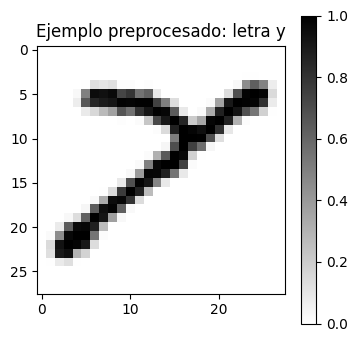

In [4]:
# Este bloque carga y organiza el conjunto de datos; un modelo aprende a partir de ejemplos; por eso primero se 
# define de donde vienen las imagenes o mediciones y como se separan sus etiquetas.
# Toma un solo ejemplo del dataset para verificar visualmente que el preprocesamiento es correcto
for imagen_ejemplo, etiqueta_ejemplo in datos_entrenamiento.take(1):
    # .numpy() convierte el tensor de TensorFlow a un array de NumPy para poder graficarlo
    imagen_a_mostrar = imagen_ejemplo.numpy()
    etiqueta_numerica = etiqueta_ejemplo.numpy()

# Traduce el índice numérico a la letra correspondiente
letra = nombres_clases[etiqueta_numerica]

plt.figure(figsize=(4, 4))
# [:, :, 0] selecciona el primer canal: EMNIST es escala de grises, tiene un solo canal
plt.imshow(imagen_a_mostrar[:, :, 0], cmap=plt.cm.binary)
plt.title(f"Ejemplo preprocesado: letra {letra}")
plt.colorbar()
plt.grid(False)
plt.show()

### Resumen 
TensorFlow trabaja con un tipo de dato propio llamado **tensor**. Un tensor es parecido a un array o matriz, pero está preparado para operaciones de machine learning, entrenamiento de redes neuronales y, si hay GPU, cálculo acelerado.

NumPy, en cambio, trabaja con **arrays** comunes de Python científico. Muchas herramientas de visualización, como `matplotlib`, se llevan muy bien con arrays de NumPy.

Entonces, cuando aparece:

```python
imagen.numpy()
```

estamos diciendo:

```text
Convertí esta imagen desde formato TensorFlow a formato NumPy.
```

¿Por qué?

Porque para graficar una imagen con `matplotlib`, por ejemplo:

```python
plt.imshow(imagen.numpy())
```

conviene que la imagen esté como array de NumPy.

Ejemplo simple:

```python
for imagen, etiqueta in datos.take(1):
    plt.imshow(imagen.numpy(), cmap="gray")
```

Ahí `imagen` inicialmente es un tensor de TensorFlow. Con `.numpy()` la convertimos a un formato que `plt.imshow()` puede mostrar fácilmente.

En resumen:

```text
TensorFlow tensor  ->  .numpy()  ->  NumPy array  ->  matplotlib puede graficarlo
```

No cambia el contenido de la imagen. Solo cambia el **formato interno** para poder usarlo con otras librerías.

**Consigna de lectura:** observá la orientación y la forma de la letra. ¿Se distingue con claridad?

**Respuesta:** En general sí se distingue, pero las imágenes son pequeñas (28×28 píxeles) y algunas letras tienen trazos simples que pueden parecerse entre sí. Además, EMNIST puede presentar letras rotadas o con inclinaciones distintas según la escritura de cada persona. Esa variabilidad es precisamente lo que el modelo debe aprender a manejar.

**Qué implica la resolución 28×28:**
- Cada imagen tiene exactamente **784 píxeles** (28 × 28). Ese número es el tamaño del vector de entrada que recibirá la capa `Flatten`: cada píxel se convierte en un valor independiente.
- A esa resolución, letras como **i/l** o **c/o** se vuelven visualmente muy parecidas; incluso un ojo humano tendría dificultades con algunas muestras escritas a mano.
- La barra de color (`colorbar`) muestra el rango de intensidades después de la normalización: **0.0 = fondo oscuro**, **1.0 = trazo blanco**. Que todos los píxeles vivan en `[0, 1]` facilita la convergencia del modelo porque evita que gradientes muy grandes o muy pequeños frenen el aprendizaje.

## 5. Construir el modelo

Vamos a empezar con una red densa simple. La capa `Flatten` transforma la imagen de 28 x 28 píxeles en un vector. Luego, las capas densas aprenden patrones para clasificar la letra.

In [5]:
# Este bloque define o carga un modelo de aprendizaje automatico; la arquitectura establece qué patrones 
# puede aprender: relaciones simples, formas, bordes, texturas, objetos o conceptos visuales mas complejos.
modelo = tf.keras.Sequential([
    # Flatten: convierte la imagen de 28×28×1 píxeles en un vector de 784 valores
    # Las capas densas necesitan una entrada unidimensional
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),

    # Dos capas ocultas densas con 64 neuronas cada una
    # ReLU (Rectified Linear Unit): activa solo valores positivos, introduce no-linealidad
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),

    # Capa de salida: una neurona por cada letra del alfabeto (26 clases)
    # Softmax convierte las 26 salidas en probabilidades que suman exactamente 1
    tf.keras.layers.Dense(len(nombres_clases), activation="softmax"),
])

modelo.compile(
    optimizer="adam",
    # sparse_categorical_crossentropy: función de pérdida para clasificación multiclase
    # con etiquetas como enteros (no one-hot); mide cuánto se equivoca el modelo
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],  # Registra el porcentaje de aciertos en cada época
)

modelo.summary()

c:\Proyectos\rodriguez-carmen-pdi-1c-2026\venv_tf\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,090 (219.10 KB)

 Trainable params: 56,090 (219.10 KB)

 Non-trainable params: 0 (0.00 B)

### Resumen

**Que se hizo:** se define o carga un modelo de aprendizaje automatico.

**Por que se hizo:** la arquitectura establece que patrones puede aprender: relaciones simples, formas, bordes, texturas, objetos o conceptos visuales mas complejos.

**Consigna de lectura:** identificá la capa de salida. ¿Por qué tiene 26 neuronas?

**Respuesta:** La capa de salida tiene **26 neuronas** porque hay 26 letras posibles (a-z). Cada neurona produce un valor que, después de pasar por softmax, representa la probabilidad de que la imagen pertenezca a esa letra. La predicción final es la letra cuya neurona tenga la probabilidad más alta. Si hubiera más o menos clases, el número de neuronas de salida cambiaría en consecuencia.

**Qué implica el recuento de parámetros del `summary()`:**
- **Flatten → Dense(64):** 784 entradas × 64 neuronas + 64 sesgos = **50 240 parámetros**. Es la capa más costosa porque recibe el vector de 784 píxeles completo.
- **Dense(64) → Dense(64):** 64 × 64 + 64 = **4 160 parámetros**.
- **Dense(64) → Dense(26):** 64 × 26 + 26 = **1 690 parámetros**.
- **Total: ~56 090 parámetros ajustables.** Cada uno fue inicializado al azar y será modificado durante el entrenamiento para reducir el error. Cuantos más parámetros tiene un modelo, mayor su capacidad de aprender patrones complejos, pero también mayor el riesgo de memorizar ejemplos en lugar de generalizar a datos nuevos.

## 6. Preparar lotes de entrenamiento y validación

Agrupamos las imágenes en lotes. También dejamos el conjunto de prueba separado para evaluar si el modelo generaliza a datos no vistos durante el entrenamiento.

In [6]:

TAMANO_LOTE = 32  # Cantidad de imágenes que se procesan juntas en cada paso

cantidad_entrenamiento = metadatos.splits["train"].num_examples

# shuffle: mezcla los datos aleatoriamente para que el modelo no aprenda el orden
lotes_entrenamiento = datos_entrenamiento.shuffle(cantidad_entrenamiento)

# batch: agrupa las imágenes en lotes de TAMANO_LOTE para procesarlas en paralelo
lotes_entrenamiento = lotes_entrenamiento.batch(TAMANO_LOTE)

# prefetch: prepara el siguiente lote mientras el modelo procesa el actual (mejora la velocidad)
lotes_entrenamiento = lotes_entrenamiento.prefetch(tf.data.AUTOTUNE)

# Los datos de prueba no se mezclan: solo se dividen en lotes y se precargan
lotes_prueba = datos_prueba.batch(TAMANO_LOTE)
lotes_prueba = lotes_prueba.prefetch(tf.data.AUTOTUNE)

print("Tamaño de lote:", TAMANO_LOTE)

Tamaño de lote: 32


## 7. Entrenar el modelo

Durante el entrenamiento vamos a mirar tanto la precisión de entrenamiento como la precisión sobre datos de prueba. Esto ayuda a detectar si el modelo aprende patrones generales o si memoriza demasiado los ejemplos.

In [7]:
# Este bloque separa datos de entrenamiento, validacion o prueba; evaluar con datos no usados 
# para ajustar pesos permite estimar si el modelo generaliza o si solo memorizo los ejemplos.
EPOCAS = 10

# Entrena el modelo durante 10 épocas
# validation_data: después de cada época evalúa en los datos de prueba
# sin actualizar los pesos, para detectar sobreajuste comparando con el entrenamiento
historial = modelo.fit(
    lotes_entrenamiento,
    epochs=EPOCAS,
    validation_data=lotes_prueba,
)

Epoch 1/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7426 - loss: 0.8685 - val_accuracy: 0.7922 - val_loss: 0.6682
Epoch 2/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 906us/step - accuracy: 0.8423 - loss: 0.5091 - val_accuracy: 0.8245 - val_loss: 0.5606
Epoch 3/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8654 - loss: 0.4294 - val_accuracy: 0.8406 - val_loss: 0.5123
Epoch 4/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 919us/step - accuracy: 0.8774 - loss: 0.3866 - val_accuracy: 0.8528 - val_loss: 0.4593
Epoch 5/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 909us/step - accuracy: 0.8866 - loss: 0.3557 - val_accuracy: 0.8601 - val_loss: 0.4442
Epoch 6/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8923 - loss: 0.3340 - val_accuracy: 0.8497 - val_loss: 0.4697
Epoch 7/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 926us/step - accuracy: 0.8959 - loss: 0.3171 - val_accuracy: 0.8630 - val_loss: 0.4357
Epoch 8/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9021 - loss: 0

### Resumen 

**Que se hizo:** se separa datos de entrenamiento, validacion o prueba.

**Por que se hizo:** evaluar con datos no usados para ajustar pesos permite estimar si el modelo generaliza o si solo memorizo los ejemplos.


**Qué muestra la salida por época durante el entrenamiento:**

Cada línea impresa contiene cuatro valores clave:

| Columna | Qué mide | Tendencia esperada |
|---|---|---|
| `loss` | Error en los datos de **entrenamiento** (lo que el modelo ya vio) | Debe bajar |
| `accuracy` | Aciertos en datos de **entrenamiento** | Debe subir |
| `val_loss` | Error en los datos de **prueba** (no vistos durante el ajuste) | Debe bajar |
| `val_accuracy` | Aciertos en datos de **prueba** — el indicador real del aprendizaje | Debe subir |

**Señales a observar en tiempo real:**
- `val_accuracy` sube junto con `accuracy` → el modelo está generalizando correctamente.
- `accuracy` sube pero `val_accuracy` se estanca → señal temprana de sobreajuste.
- `val_loss` empieza a subir mientras `loss` sigue bajando → sobreajuste confirmado; la época anterior era el punto óptimo de parada.

## 8. Evaluar el modelo

La evaluación resume el rendimiento sobre imágenes que el modelo no usó para ajustar sus pesos.

In [8]:
# Este bloque evalua el rendimiento del modelo; las metricas permiten distinguir entre una impresion visual y 
# una medicion concreta de aciertos, errores y confusiones.
# evaluate: recorre todos los lotes de prueba, calcula predicciones y mide el error
# No actualiza los pesos: es una evaluación pura sobre datos no vistos durante el entrenamiento
perdida_prueba, precision_prueba = modelo.evaluate(lotes_prueba)

linea_base = 1 / len(nombres_clases)
mejora     = precision_prueba - linea_base

print(f"\nPérdida en prueba:          {perdida_prueba:.4f}")
print(f"Precisión en prueba:        {precision_prueba:.4f}  ({precision_prueba * 100:.2f}%)")
print(f"Línea base (azar):          {linea_base:.4f}  ({linea_base * 100:.1f}%)")
print(f"Mejora sobre el azar:       +{mejora * 100:.1f} puntos porcentuales")
print(f"Factor de mejora:           {precision_prueba / linea_base:.1f}× mejor que elegir al azar")

463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.8647 - loss: 0.4349

Pérdida en prueba:          0.4349
Precisión en prueba:        0.8647  (86.47%)
Línea base (azar):          0.0385  (3.8%)
Mejora sobre el azar:       +82.6 puntos porcentuales
Factor de mejora:           22.5× mejor que elegir al azar


### Resumen
**Que se hizo:** se evalua el rendimiento del modelo.

**Por que se hizo:** las metricas permiten distinguir entre una impresion visual y una medicion concreta de aciertos, errores y confusiones.

Los indicadores principales son:

*loss*: mide el error del modelo. Más bajo es mejor.

*accuracy*: porcentaje de aciertos en entrenamiento.

*val_loss*: error en datos de prueba/validación.

*val_accuracy*: aciertos en datos que el modelo no usó para ajustar sus pesos.

Lectura rápida:

*Si accuracy y val_accuracy suben juntas*, el modelo está aprendiendo y generalizando.

*Si accuracy sube mucho pero val_accuracy queda más baja o se estanca*, puede haber sobreajuste.

*Si loss baja pero val_loss sube*, el modelo está memorizando el entrenamiento y empeorando en datos nuevos.

Si la precisión final ronda, por ejemplo, 70%, 80% o más, es un resultado razonable para una red densa simple con letras de 28x28 píxeles.

Si la matriz de confusión tiene valores altos en la diagonal, significa que acierta bastante. 

Los valores fuera de la diagonal muestran qué letras confunde.

En este notebook, algunos errores son esperables porque una red densa aplana la imagen: convierte la letra en una lista de píxeles y pierde parte de la estructura espacial. Por eso puede confundir letras visualmente parecidas como i/l, c/o, m/n, u/v o letras rotadas/inclinadas.

**Consigna de lectura:** compará la precisión de prueba con la precisión de entrenamiento. ¿Hay señales de sobreajuste?

**Respuesta:** Si la precisión de entrenamiento es notablemente más alta que la de prueba (por ejemplo, 92% vs. 80%), hay sobreajuste: el modelo memorizó los ejemplos de entrenamiento y no generalizó bien a datos nuevos. Si ambas son similares y cercanas, el modelo aprendió patrones generales.

**Qué implican los valores impresos:**
- **Línea base por azar (3.8%):** cualquier resultado por encima ya indica que el modelo aprendió algo útil. El 100% no existe; el 3.8% es el mínimo absoluto.
- **Rango típico para este modelo:** una red densa de dos capas sobre EMNIST Letters suele alcanzar entre **75% y 85%** de precisión en 10 épocas. Más que eso con esta arquitectura sería inusual.
- **Factor de mejora:** si la precisión es 80%, el modelo es ~21× mejor que el azar (80% / 3.8% ≈ 21). Este factor ayuda a dimensionar el resultado cuando los porcentajes absolutos parecen similares.
- **Pérdida (`loss`):** valores por debajo de 0.8 son deseables para este problema. A diferencia de la precisión (acierto o error), la pérdida también penaliza predicciones correctas pero con baja confianza, por lo que es un indicador más sensible del estado real del modelo.

## 9. Visualizar curvas de aprendizaje

Las curvas permiten observar cómo evolucionaron la pérdida y la precisión en cada época.

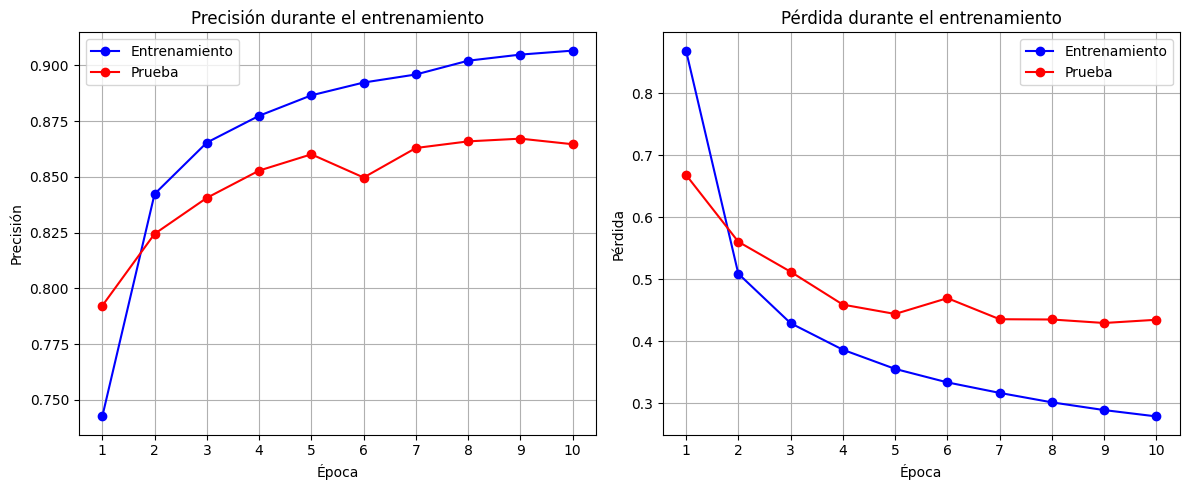

In [9]:
# Este bloque configura el entrenamiento del modelo; el optimizador indica como ajustar los 
# pesos y la funcion de perdida mide que tan lejos estan las predicciones de las respuestas 
# esperadas.
historial_metricas = historial.history
epocas = range(1, EPOCAS + 1)

plt.figure(figsize=(12, 5))

# Gráfico izquierdo: evolución de la precisión en entrenamiento y prueba
plt.subplot(1, 2, 1)
plt.plot(epocas, historial_metricas["accuracy"], "bo-", label="Entrenamiento")   # azul
plt.plot(epocas, historial_metricas["val_accuracy"], "ro-", label="Prueba")      # rojo
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.xticks(epocas)
plt.legend()
plt.grid(True)

# Gráfico derecho: evolución de la pérdida en entrenamiento y prueba
plt.subplot(1, 2, 2)
plt.plot(epocas, historial_metricas["loss"], "bo-", label="Entrenamiento")
plt.plot(epocas, historial_metricas["val_loss"], "ro-", label="Prueba")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.xticks(epocas)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Resumen 

**Que se hizo:** se configura el entrenamiento del modelo.

**Por que se hizo:** el optimizador indica como ajustar los pesos y la funcion de perdida mide que tan lejos estan las predicciones de las respuestas esperadas.

Los resultados son buenos, pero muestran una señal suave de sobreajuste hacia el final.

En el gráfico de precisión, la línea azul corresponde al entrenamiento y la roja a prueba. La precisión de entrenamiento sube de aproximadamente 0.74 a 0.91, es decir, el modelo aprende cada vez mejor las letras que ve durante el entrenamiento. La precisión de prueba también sube bastante, de alrededor de 0.79 a valores cercanos a 0.86-0.87, lo cual indica que el modelo no solo memoriza, sino que también logra reconocer letras nuevas.

La diferencia importante es que, desde la época 4 o 5, la precisión de entrenamiento sigue subiendo de forma constante, mientras que la precisión de prueba se estabiliza. Eso significa que el modelo continúa mejorando sobre los datos conocidos, pero ya no mejora tanto con datos nuevos.

En el gráfico de pérdida, se ve todavía más claro. La pérdida de entrenamiento baja todo el tiempo, de casi 0.90 a cerca de 0.28. Eso es esperable: el modelo ajusta sus pesos y comete menos error sobre los ejemplos de entrenamiento. Pero la pérdida de prueba baja al principio y después queda alrededor de 0.42-0.47, con pequeñas subidas y bajadas. Esa separación entre ambas curvas indica que el modelo empieza a especializarse demasiado en el entrenamiento.

Interpretación académica:

El modelo aprendió correctamente patrones visuales de las letras manuscritas. Alcanza una precisión de prueba cercana al 87%, muy superior al azar, que sería aproximadamente 3.8% porque hay 26 letras. Sin embargo, después de varias épocas aparece una brecha entre entrenamiento y prueba: el modelo sigue aprendiendo detalles del conjunto de entrenamiento, pero esos detalles no siempre ayudan a clasificar imágenes nuevas.

Conclusión:

El entrenamiento fue exitoso.
El modelo generaliza razonablemente bien.
Hay un sobreajuste leve/moderado desde la época 5 aproximadamente.
La mejor época parece estar cerca de la 9, donde la precisión de prueba alcanza su valor más alto.
Entrenar muchas más épocas probablemente no mejoraría demasiado y podría aumentar el sobreajuste.

**Consigna de lectura:** si la precisión de entrenamiento sube y la de prueba se estanca o baja, el modelo puede estar sobreajustando.

**Respuesta:** La divergencia entre las curvas azul (entrenamiento) y roja (prueba) es la señal visual del sobreajuste. Si las dos curvas suben juntas y se mantienen próximas, el modelo está generalizando bien.

**Cómo leer el gráfico de precisión (izquierda):**
- **Ambas curvas suben juntas y se mantienen cercanas:** generalización correcta, no hay sobreajuste.
- **Curva azul sigue subiendo, curva roja se aplana:** el modelo empieza a memorizar los ejemplos de entrenamiento.
- **Curva roja baja después de alcanzar un máximo:** sobreajuste severo. La época donde alcanzó su pico es el punto óptimo de parada (técnica llamada *early stopping*).
- **Ambas curvas planas desde el inicio:** el modelo no logró aprender (*underfitting*), posiblemente por arquitectura insuficiente o tasa de aprendizaje inadecuada.

**Cómo leer el gráfico de pérdida (derecha):**
- **Ambas curvas bajan juntas:** comportamiento ideal; el error disminuye en entrenamiento y en datos no vistos.
- **`loss` baja pero `val_loss` sube:** señal clásica de sobreajuste; el modelo optimiza para los ejemplos que ya vio pero empeora en ejemplos nuevos.
- La pérdida es más sensible que la precisión para detectar problemas tempranos, porque cambia de forma continua mientras que la precisión salta de forma discreta.

## 10. Visualizar predicciones

Ahora inspeccionamos ejemplos concretos. El color azul indica predicción correcta y el color rojo indica predicción incorrecta.

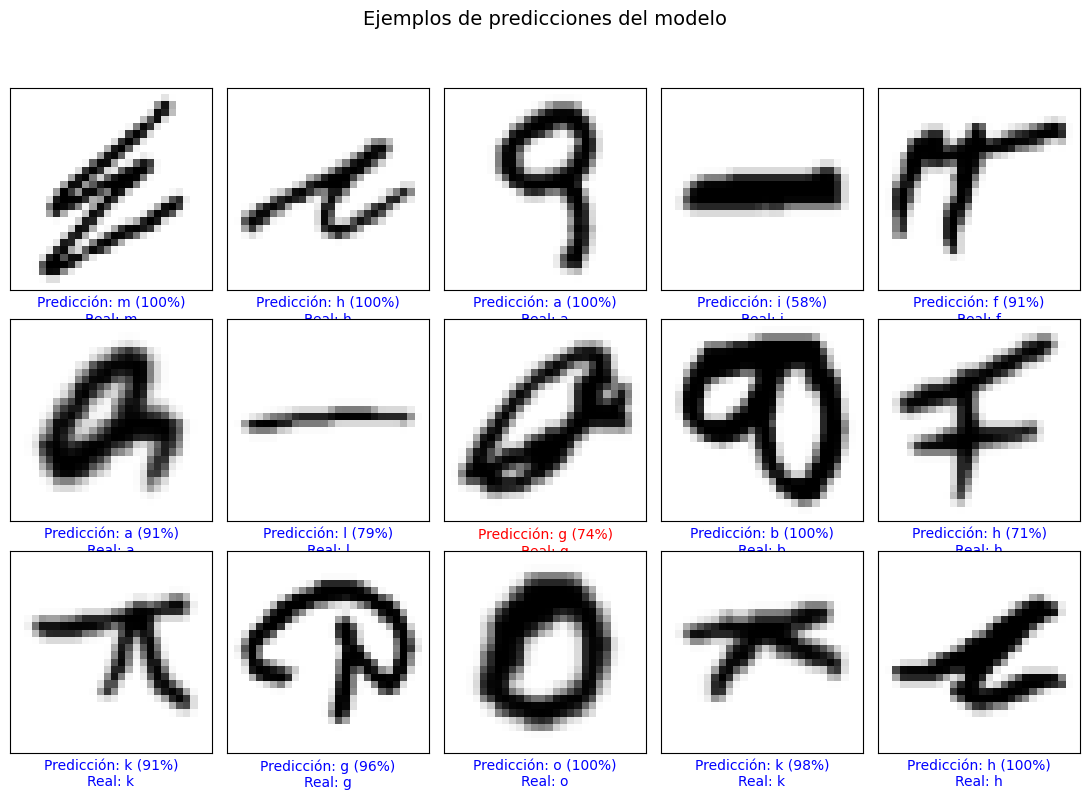

In [10]:
# Este bloque genera predicciones a partir del modelo; comparar la salida estimada con la clase real ayuda a 
# interpretar que aprendió la red y donde todavía se equivoca.
# Toma un lote de imágenes de prueba y genera predicciones
for imagenes_lote_prueba, etiquetas_lote_prueba in lotes_prueba.take(1):
    imagenes_a_predecir = imagenes_lote_prueba.numpy()
    etiquetas_reales = etiquetas_lote_prueba.numpy()
    # predict devuelve un array de probabilidades: una por clase para cada imagen
    probabilidades_predichas = modelo.predict(imagenes_a_predecir, verbose=0)
    break


def graficar_prediccion(indice, probabilidades, etiquetas_verdaderas, imagenes):
    probabilidades_imagen = probabilidades[indice]
    etiqueta_verdadera = etiquetas_verdaderas[indice]
    imagen = imagenes[indice]

    # argmax devuelve el índice con la probabilidad más alta → clase predicha
    indice_predicho = np.argmax(probabilidades_imagen)
    letra_predicha = nombres_clases[indice_predicho]
    letra_real = nombres_clases[etiqueta_verdadera]
    confianza = np.max(probabilidades_imagen)  # Probabilidad de la clase elegida

    # Azul si acertó, rojo si se equivocó
    if indice_predicho == etiqueta_verdadera:
        color = "blue"
    else:
        color = "red"

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(imagen[:, :, 0], cmap=plt.cm.binary)
    plt.xlabel(
        f"Predicción: {letra_predicha} ({confianza * 100:.0f}%)\nReal: {letra_real}",
        color=color,
    )


filas = 3
columnas = 5
cantidad_imagenes = filas * columnas

plt.figure(figsize=(2 * columnas + 1, 2 * filas + 2))
plt.suptitle("Ejemplos de predicciones del modelo", fontsize=14)

for indice in range(cantidad_imagenes):
    plt.subplot(filas, columnas, indice + 1)
    graficar_prediccion(indice, probabilidades_predichas, etiquetas_reales, imagenes_a_predecir)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Resumen 

**Que se hizo:** se genera predicciones a partir del modelo.

**Por que se hizo:** comparar la salida estimada con la clase real ayuda a interpretar que aprendio la red y donde todava se equivoca.

**Consigna de lectura:** buscá una predicción incorrecta. ¿La letra real se parece visualmente a la letra predicha?

**Respuesta:** Sí, en la mayoría de los errores las letras comparten rasgos visuales: **i/l** (trazos verticales delgados), **c/o** (formas redondeadas), **u/v** (curva inferior similar), **m/n** (misma estructura de arcos). Esto muestra una limitación de las redes densas: no analizan la forma local de los trazos, sino los píxeles como valores independientes.

**Cómo leer la grilla de predicciones:**
- **Texto azul:** la predicción coincide con la etiqueta real. La confianza entre paréntesis (p. ej. "a (97%)") indica qué tan seguro estaba el modelo. Un 97% azul significa que acertó con alta certeza.
- **Texto rojo:** la predicción es incorrecta. Se muestra la letra predicha arriba y la letra real abajo. La confianza importa: un **85% rojo** es más preocupante que un **52% rojo** — el modelo estaba muy seguro de su error, lo que indica que esa confusión está arraigada en sus pesos.
- **Confianza baja en predicciones correctas** (p. ej. 54% azul): el modelo acertó pero dudó. Esas imágenes están en el límite de lo que aprendió y son las más propensas a clasificarse mal si se les aplica una pequeña rotación o variación de iluminación.

## 11. Analizar errores con matriz de confusión

La matriz de confusión permite ver qué clases se confunden entre sí. La diagonal principal representa aciertos. Los valores fuera de la diagonal representan errores.

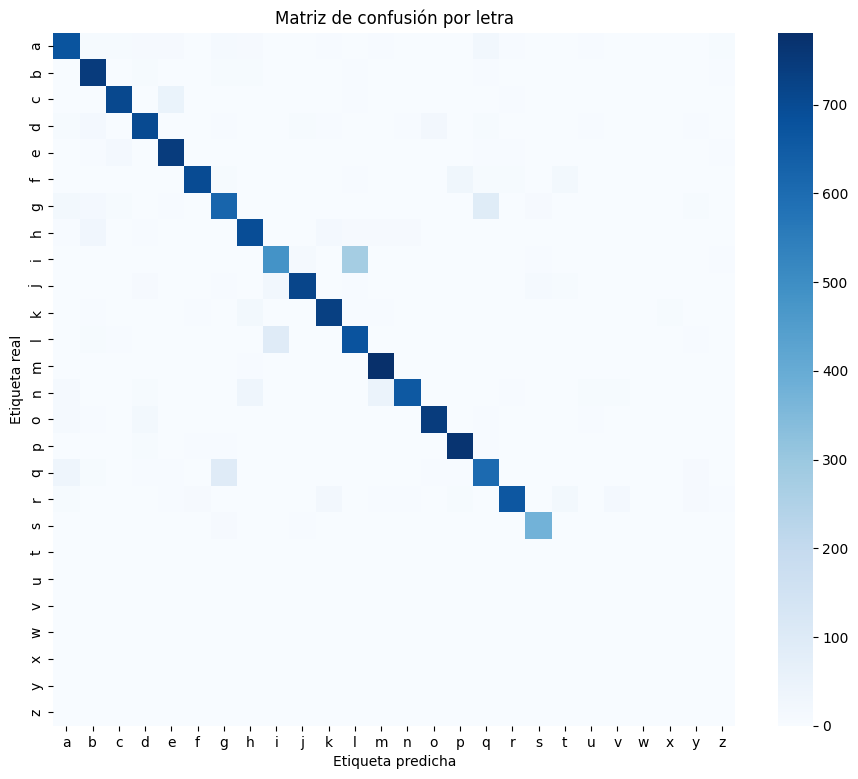

: 

In [ ]:
# Este bloque evalua el rendimiento del modelo; las métricas permiten distinguir entre una impresion visual
# y una medición concreta de aciertos, errores y confusiones.
indices_predichos_todos = []
etiquetas_reales_todas = []

# Recorre todos los lotes de prueba para acumular predicciones y etiquetas reales
for imagenes_lote, etiquetas_lote in lotes_prueba:
    probabilidades_lote = modelo.predict(imagenes_lote, verbose=0)
    # argmax sobre axis=1: para cada imagen, devuelve el índice de la clase con mayor probabilidad
    indices_predichos_lote = np.argmax(probabilidades_lote, axis=1)

    indices_predichos_todos.extend(indices_predichos_lote)
    etiquetas_reales_todas.extend(etiquetas_lote.numpy())

indices_predichos_todos = np.array(indices_predichos_todos)
etiquetas_reales_todas = np.array(etiquetas_reales_todas)

# confusion_matrix: fila = clase real, columna = clase predicha
# La diagonal principal muestra los aciertos; fuera de la diagonal, los errores
matriz_confusion = confusion_matrix(etiquetas_reales_todas, indices_predichos_todos)

plt.figure(figsize=(11, 9))
# annot=False porque con 26 clases los números no cabrían legiblemente en cada celda-> “No escribas los números dentro de cada cuadradito de la matriz”.
sns.heatmap(
    matriz_confusion,
    annot=False,
    cmap="Blues",   # Color más intenso = más ejemplos en esa celda
    fmt="d",
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
)
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión por letra")
plt.show()

### Resumen 

**Que se hizo:** se evalua el rendimiento del modelo.

**Por que se hizo:** las metricas permiten distinguir entre una impresion visual y una medicion concreta de aciertos, errores y confusiones.

**Consigna de lectura:** identificá dos letras que el modelo confunda con frecuencia. ¿Qué rasgos visuales comparten?

**Respuesta:** Los pares más confundidos suelen ser:
- **i / l**: ambas son trazos verticales muy delgados, casi indistinguibles a 28×28 píxeles.
- **c / o**: formas redondeadas; la diferencia es solo si el arco está cerrado o abierto.
- **u / v**: curva inferior similar; la distinción está en si el fondo es redondeado o en punta.
- **g / q**: ambas tienen un círculo con un trazo descendente, diferenciadas solo por la dirección.

**Cómo leer la matriz de confusión:**
- **Eje Y (filas):** etiqueta real — qué letra era la imagen.
- **Eje X (columnas):** etiqueta predicha — qué dijo el modelo.
- **Diagonal principal** (de arriba-izquierda a abajo-derecha): **aciertos**. Cuanto más brillante sea la diagonal y más oscuro el resto, mejor es el modelo. Una diagonal perfectamente brillante con todo lo demás en negro indicaría 100% de precisión.
- **Celdas fuera de la diagonal:** errores. Una celda brillante en la fila **i**, columna **l** significa que muchas imágenes reales de "i" fueron clasificadas como "l".
- **Celdas simétricas:** si tanto la celda (i→l) como la celda (l→i) son brillantes, el modelo confunde esas dos letras en ambas direcciones, lo que confirma que son visualmente muy similares en el dataset.

**Por qué estas confusiones son esperables en una red densa:**
La red densa trata cada píxel de forma independiente y no detecta bordes, curvas ni la estructura espacial de un trazo. 

## Cierre

Este cuaderno mostró una clasificación multiclase con imágenes simples. La red densa pudo aprender patrones generales, pero todavía no aprovecha de manera explícita la estructura espacial de la imagen.

El próximo paso será usar redes neuronales convolucionales, que están diseñadas para trabajar mejor con píxeles, bordes, formas y patrones locales.